# HAR Model on the MHAR Feature Set

**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance 
of the Heterogeneous Autoregressive (HAR) model of Corsi (2009) on the 
$\mathcal{M}_{\mathrm{HAR}}$ feature set for the EURO STOXX 50 index over the 
period 1999 - 2020, following the methodology of Christensen et al. (2023). We evaluate forecast accuracy using the Mean Squared Error (MSE) 
and report the relative MSE with respect to the HAR benchmark. The HAR model 
serves as the primary benchmark against which all other models are compared 
throughout this thesis.

The model is defined as:

$$RV_{t+1} = \beta_0 + \beta_d RV_t + \beta_w \overline{RV}_t^{(w)} + 
\beta_m \overline{RV}_t^{(m)} + \varepsilon_{t+1}$$

where the predictors are the current day's realized variance measures:

- $RV_t$ (RVD) — daily realized variance
- $\overline{RV}_t^{(w)} = \frac{1}{5}\sum_{i=0}^{4} RV_{t-i}$ (RVW) — 
5-day rolling average of realized variance
- $\overline{RV}_t^{(m)} = \frac{1}{22}\sum_{i=0}^{21} RV_{t-i}$ (RVM) — 
22-day rolling average of realized variance

The model is estimated via Ordinary Least Squares (OLS) using a rolling window 
of fixed length equal to the combined training and validation set (4,389 
observations), rolling forward one day at a time across the test period of 
1,099 observations (2016-04-20 to 2020-08-05).

## 1.1 Loading Data

In [75]:
import pandas as pd
import numpy as np

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()

Shape: (5488, 30)
Date range: 1999-01-05 to 2020-08-05
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,CISS,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000078,0.000093,0.000129,-9.462355,-9.288024,-8.958306,0.000046,0.000032,0.000000,-0.000682,...,0.2085,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000058
1999-01-06,0.000058,0.000092,0.000123,-9.760055,-9.290171,-9.005038,0.000043,0.000014,0.000000,-0.000682,...,0.2214,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000139
1999-01-07,0.000139,0.000102,0.000121,-8.877543,-9.192627,-9.023153,0.000072,0.000068,-0.015530,-0.003788,...,0.2254,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000108
1999-01-08,0.000108,0.000106,0.000112,-9.130603,-9.148418,-9.097084,0.000055,0.000053,-0.003409,-0.003788,...,0.2297,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000166
1999-01-11,0.000166,0.000110,0.000110,-8.702667,-9.116188,-9.115384,0.000076,0.000090,-0.019561,-0.007700,...,0.2583,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000115


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)

Following Christensen et al. (2023), we split the sample into a training set (70%), 
validation set (10%), and test set (20%). The test set is reserved exclusively for 
out-of-sample evaluation and no estimation or tuning is conducted on it.

In [79]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")

Total observations: 5488

Train:      1999-01-05 to 2014-02-25 (3841 obs, 70.0%)
Validation: 2014-02-26 to 2016-04-19 (548 obs, 10.0%)
Test:       2016-04-20 to 2020-08-05 (1099 obs, 20.0%)


## 3. HAR Model
### 3.1 Model Specification

The baseline HAR model is defined as:

$$RV_{t+1} = \beta_0 + \beta_d RV_t + \beta_w \overline{RV}_t^{(w)} + \beta_m \overline{RV}_t^{(m)} + \varepsilon_{t+1}$$

### 3.2 Feature Set Construction

In [84]:
# Define target and feature set for MHAR
y      = MALL["RV_target"]
X_MHAR = MALL[["RVD", "RVW", "RVM"]]

print(f"Target variable: RV_target")
print(f"Predictors: {X_MHAR.columns.tolist()}")
print(f"\nFirst few rows:")
print(pd.concat([y, X_MHAR], axis=1).head())

Target variable: RV_target
Predictors: ['RVD', 'RVW', 'RVM']

First few rows:
            RV_target       RVD       RVW       RVM
Date                                               
1999-01-05   0.000058  0.000078  0.000093  0.000129
1999-01-06   0.000139  0.000058  0.000092  0.000123
1999-01-07   0.000108  0.000139  0.000102  0.000121
1999-01-08   0.000166  0.000108  0.000106  0.000112
1999-01-11   0.000115  0.000166  0.000110  0.000110


### 3.3 Rolling Window Estimation and Forecasting

Following Christensen et al. (2023), the HAR model is estimated via OLS using a rolling 
window of fixed length equal to the combined training and validation set (3,841 + 548 = 4,389 
observations). The window rolls forward one day at a time across the test set, producing 
one-step-ahead forecasts. Negative forecasts are replaced by the minimum in-sample realized 
variance following the insanity filter of Bollerslev, Patton, and Quaedvlieg (2016).

In [87]:
from sklearn.linear_model import LinearRegression

# Rolling window length = train + validation
window = n_train + n_val

forecasts_HAR = []
dates_test    = []

for i in range(n_test):
    # Extract rolling window
    X_window = X_MHAR.iloc[i : i + window].values
    y_window = y.iloc[i : i + window].values
    
    # OLS estimation
    model = LinearRegression()
    model.fit(X_window, y_window)
    
    # One-step-ahead forecast using time t predictors
    X_forecast = X_MHAR.iloc[i + window].values.reshape(1, -1)
    forecast   = model.predict(X_forecast)[0]
    
    # Insanity filter: replace negative forecasts with minimum in-sample RV
    min_rv   = y_window.min()
    forecast = max(forecast, min_rv)
    
    forecasts_HAR.append(forecast)
    dates_test.append(MALL.index[i + window])

print(f"Forecasts generated: {len(forecasts_HAR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")

Forecasts generated: 1099
Forecast period: 2016-04-20 to 2020-08-05


### 3.4 Out-of-Sample Performance Evaluation

Following Christensen et al. (2023), out-of-sample forecast accuracy is evaluated using 
the Mean Squared Error (MSE):

$$MSE = \frac{1}{T}\sum_{t \in \text{test}} (RV_{t+1} - \hat{f}(Z_t))^2$$

where $\hat{f}(Z_t)$ is the one-step-ahead forecast and $T$ is the number of test observations.

In [91]:
# Collect results
results_HAR = pd.DataFrame({
    "RV_actual":   y.loc[dates_test].values,
    "RV_forecast": forecasts_HAR
}, index=dates_test)

# Compute out-of-sample MSE
mse_HAR = np.mean((results_HAR["RV_actual"] - results_HAR["RV_forecast"])**2)

print(f"Out-of-sample MSE (HAR): {mse_HAR:.6e}")
print(f"\nFirst few forecasts vs actuals:")
print(results_HAR.head(10).to_string())

Out-of-sample MSE (HAR): 2.221336e-08

First few forecasts vs actuals:
            RV_actual  RV_forecast
2016-04-20   0.000131     0.000112
2016-04-21   0.000068     0.000134
2016-04-22   0.000079     0.000109
2016-04-25   0.000080     0.000099
2016-04-26   0.000045     0.000101
2016-04-27   0.000157     0.000084
2016-04-28   0.000219     0.000128
2016-04-29   0.000087     0.000163
2016-05-02   0.000107     0.000113
2016-05-03   0.000109     0.000121


### 3.4.1 Save Forecasts 

In [96]:
import os

# Save HAR forecasts to CSV for comparison with other models
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

# Save forecasts
results_HAR.to_csv(os.path.join(forecast_path, "forecasts_HAR.csv"))

# Save MSE summary
mse_summary_HAR = pd.DataFrame({
    "Model": ["HAR"],
    "MSE":   [mse_HAR],
    "RMSE":  [np.sqrt(mse_HAR)],
    "MAE":   [np.mean(np.abs(results_HAR["RV_actual"] - results_HAR["RV_forecast"]))],
    "Mean_Error": [np.mean(results_HAR["RV_actual"] - results_HAR["RV_forecast"])],
}).set_index("Model")

mse_summary_HAR.to_csv(os.path.join(forecast_path, "mse_summary_HAR.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Files saved:")
print(f"  - forecasts_HAR.csv ({len(results_HAR)} rows)")
print(f"  - mse_summary_HAR.csv")
print(f"\nHAR MSE: {mse_HAR:.6e}")

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Files saved:
  - forecasts_HAR.csv (1099 rows)
  - mse_summary_HAR.csv

HAR MSE: 2.221336e-08


## 4. Results
### 4.1 Forecast Visualization

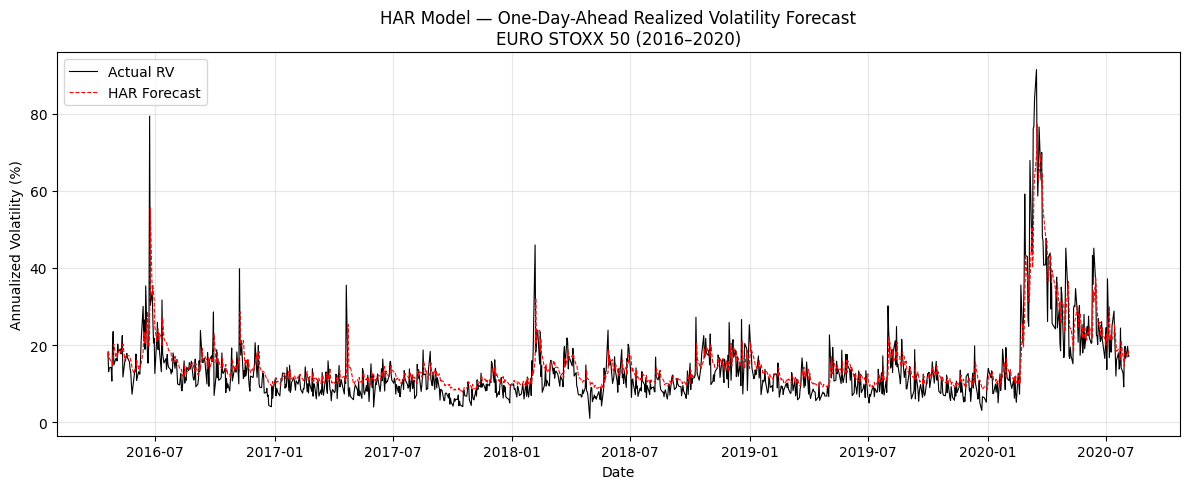


Summary of forecast errors:
Mean error:  -4.057863e-06
RMSE:        1.490415e-04
MAE:         5.592501e-05


In [99]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual":   np.sqrt(results_HAR["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_HAR["RV_forecast"] * 252) * 100
}, index=results_HAR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"],   label="Actual RV",       color="black",  linewidth=0.8)
ax.plot(results_plot["Forecast"], label="HAR Forecast",    color="red",    linewidth=0.8, linestyle="--")
ax.set_title("HAR Model — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_HAR["RV_actual"] - results_HAR["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_HAR):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")

### 4.2 Forecast Performance Summary

In [102]:
from IPython.display import display

# Summary table of forecast performance
performance = pd.DataFrame({
    "Model": ["HAR"],
    "MSE":   [mse_HAR],
    "RMSE":  [np.sqrt(mse_HAR)],
    "MAE":   [errors.abs().mean()],
    "Mean Error": [errors.mean()],
    "Relative MSE": [1.0]  # HAR is the benchmark, so relative MSE = 1
}).set_index("Model")

# Style the table
styled_performance = (
    performance.style
    .set_caption(
        "Table 3: Out-of-Sample Forecast Performance — HAR Model\n"
        f"EURO STOXX 50 Test Period: {dates_test[0].date()} to {dates_test[-1].date()} "
        f"({n_test} observations)"
    )
    .format({
        "MSE":         "{:.6e}",
        "RMSE":        "{:.6e}",
        "MAE":         "{:.6e}",
        "Mean Error":  "{:.6e}",
        "Relative MSE": "{:.4f}"
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [
             ("font-size", "12px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding-bottom", "8px"),
             ("color", "black"),
             ("caption-side", "top"),
         ]},
        {"selector": "thead tr th",
         "props": [
             ("background-color", "white"),
             ("color", "black"),
             ("font-size", "11px"),
             ("text-align", "center"),
             ("padding", "6px 10px"),
             ("border-top", "2px solid black"),
             ("border-bottom", "1px solid black"),
             ("font-weight", "bold"),
         ]},
        {"selector": "tbody tr th",
         "props": [
             ("font-size", "11px"),
             ("font-weight", "bold"),
             ("text-align", "left"),
             ("padding", "4px 10px"),
             ("color", "black"),
             ("background-color", "white"),
             ("border-right", "1px solid black"),
         ]},
        {"selector": "tbody tr td",
         "props": [
             ("font-size", "11px"),
             ("text-align", "right"),
             ("padding", "4px 10px"),
             ("background-color", "white"),
             ("color", "black"),
         ]},
        {"selector": "tbody tr:last-child td, tbody tr:last-child th",
         "props": [("border-bottom", "2px solid black")]},
        {"selector": "table",
         "props": [
             ("border-collapse", "collapse"),
             ("width", "100%"),
         ]},
        {"selector": "td, th",
         "props": [
             ("border-left", "none"),
             ("border-right", "none"),
         ]},
    ])
)

display(styled_performance)

,MSE,RMSE,MAE,Mean Error,Relative MSE
Model,,,,,
HAR,2.221336e-08,1.490415e-04,5.592501e-05,-4.057863e-06,1.0000
